# Ddri 군집화 전처리 설명 노트북

이 노트북은 군집화 이전에 어떤 데이터 정합화와 품질 점검을 했는지 읽는 사람 기준으로 정리한 문서다.

## 이 노트북에서 확인할 내용

- 제거 기준이 무엇이었는지
- 전처리 전후 행 수가 얼마나 달라졌는지
- 중복 로그가 어느 정도인지
- IQR 기준 극단치 후보가 얼마나 있었는지
- 발표 자료에서 어떤 차트를 근거로 사용할 수 있는지

## 1. 기본 설정과 입력 경로

전처리 산출물은 `02_preprocessing/data`와 `02_preprocessing/images`에 분리 저장한다. 이 노트북은 원본 CSV 전체를 다시 읽는 대신, 전처리 결과 로그와 요약표를 바탕으로 기준을 설명한다.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path('/Users/cheng80/Desktop/ddri_work')
DATA_DIR = BASE_DIR / 'works' / '01_clustering' / '02_preprocessing' / 'data'
IMG_DIR = BASE_DIR / 'works' / '01_clustering' / '02_preprocessing' / 'images'

cleaning_log_path = DATA_DIR / 'ddri_cleaning_log.csv'
cleaning_summary_path = DATA_DIR / 'ddri_cleaning_summary_by_group.csv'
dup_summary_path = DATA_DIR / 'ddri_duplicate_check_summary.csv'
dup_file_path = DATA_DIR / 'ddri_duplicate_check_by_file.csv'
outlier_path = DATA_DIR / 'ddri_feature_iqr_outlier_summary.csv'

## 2. 전처리 로그 확인

전처리는 파일별로 남겨두고, 이후 그룹 단위로 다시 합산했다. 이 로그는 나중에 어느 단계에서 얼마나 줄었는지 역추적하기 위한 근거다.

In [2]:
cleaning_log = pd.read_csv(cleaning_log_path)
display(cleaning_log.head())
print('로그 파일 수:', cleaning_log['file_name'].nunique())

,file_name,rows_before,rows_after,dropped_missing,dropped_nonpositive,dropped_noncommon_rent,dropped_outside_gangnam_return,group_name
0,2301_강남구_따릉이_이용정보.csv,34937,31247,0,2778,912,0,train_2023
1,2302_강남구_따릉이_이용정보.csv,49372,44539,0,3480,1353,0,train_2023
2,2303_강남구_따릉이_이용정보.csv,80572,72861,0,5431,2280,0,train_2023
3,2304_강남구_따릉이_이용정보.csv,91717,82939,0,6235,2543,0,train_2023
4,2305_강남구_따릉이_이용정보.csv,107880,98133,0,6786,2961,0,train_2023


로그 파일 수: 36


## 3. 그룹별 요약 확인

아래 표는 2023 학습, 2024 학습, 2025 테스트를 각각 얼마나 정제했는지 보여준다. 발표에서는 이 표와 차트를 함께 사용하면 제거 기준을 설명하기 쉽다.

In [3]:
cleaning_summary = pd.read_csv(cleaning_summary_path)
display(cleaning_summary)

,group_name,rows_before,rows_after,dropped_missing,dropped_nonpositive,dropped_noncommon_rent,dropped_outside_gangnam_return
0,test_2025,869397,825111,0,15022,29264,0
1,train_2023,1012480,917202,0,68978,26300,0
2,train_2024,1014918,943381,0,54057,17480,0


## 4. 중복 및 극단치 점검

중복 로그는 전체 규모 대비 매우 적었고, IQR 기준 극단치 후보는 있었지만 1차 군집화에서는 자동 제거하지 않았다. 이유는 일부 극단치가 실제 고수요 거점을 반영할 수 있기 때문이다.

In [4]:
dup_summary = pd.read_csv(dup_summary_path)
dup_by_file = pd.read_csv(dup_file_path)
outlier_summary = pd.read_csv(outlier_path)

print('중복 요약')
display(dup_summary)
print('중복 발생 파일 예시')
display(dup_by_file.head())
print('IQR 기준 극단치 후보 요약')
display(outlier_summary)

중복 요약


,files,rows,dup_all,dup_key
0,36,2896795,21,21


중복 발생 파일 예시


,file,rows,dup_all,dup_key
0,2301_강남구_따릉이_이용정보.csv,34937,0,0
1,2302_강남구_따릉이_이용정보.csv,49372,0,0
2,2303_강남구_따릉이_이용정보.csv,80572,0,0
3,2304_강남구_따릉이_이용정보.csv,91717,0,0
4,2305_강남구_따릉이_이용정보.csv,107880,0,0


IQR 기준 극단치 후보 요약


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,avg_rental,8.656448,19.009784,10.353336,-6.873557,34.539788,12
1,rental_std,5.547695,11.063102,5.515407,-2.725415,19.336213,6
2,weekday_avg,9.433483,20.984080,11.550597,-7.892412,38.309975,11
3,weekend_avg,6.867890,15.705529,8.837638,-6.388567,28.961986,13
4,peak_ratio,0.338877,0.403111,0.064234,0.242525,0.499463,6
5,night_ratio,0.109443,0.156774,0.047330,0.038448,0.227769,6
6,weekday_weekend_gap,0.913976,6.099563,5.185587,-6.864404,13.877943,11


## 5. 전처리 근거 차트

전처리 파트는 숫자 표만으로는 설명이 약해질 수 있으므로, 아래 차트를 함께 유지한다.

- 전처리 전후 행 수 비교
- 제거 사유별 건수
- 중복률
- IQR 기준 극단치 후보 수

ddri_cleaning_before_after.png exists= True


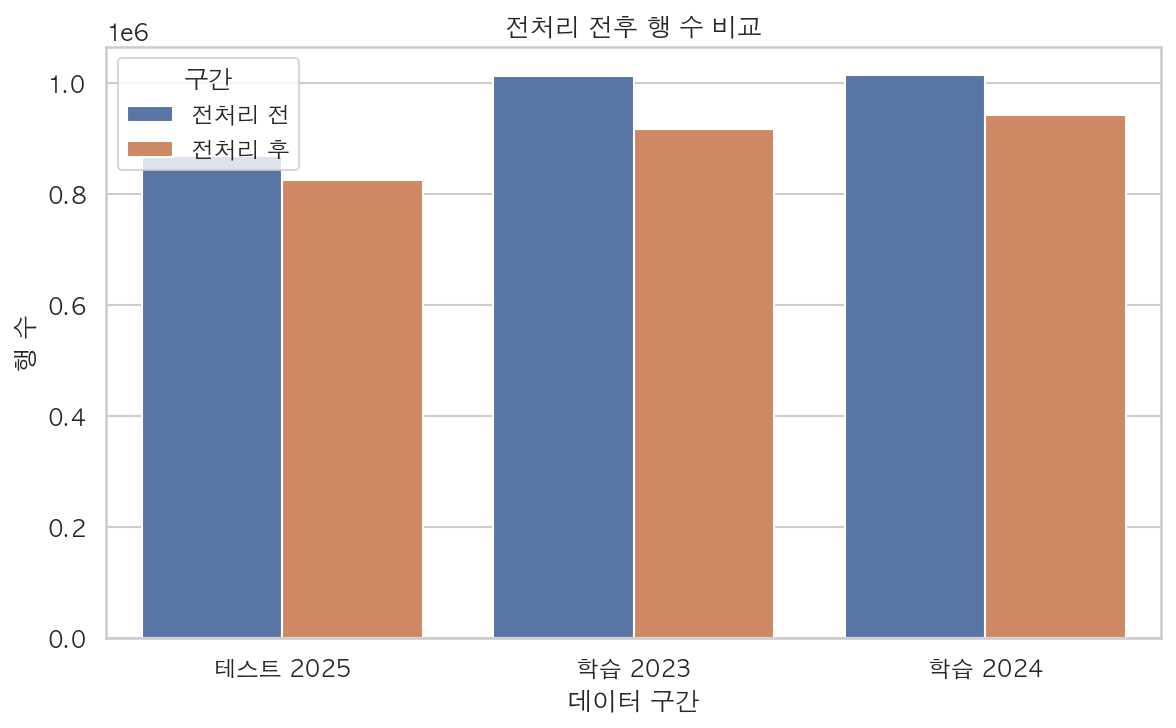

ddri_cleaning_drop_reasons.png exists= True


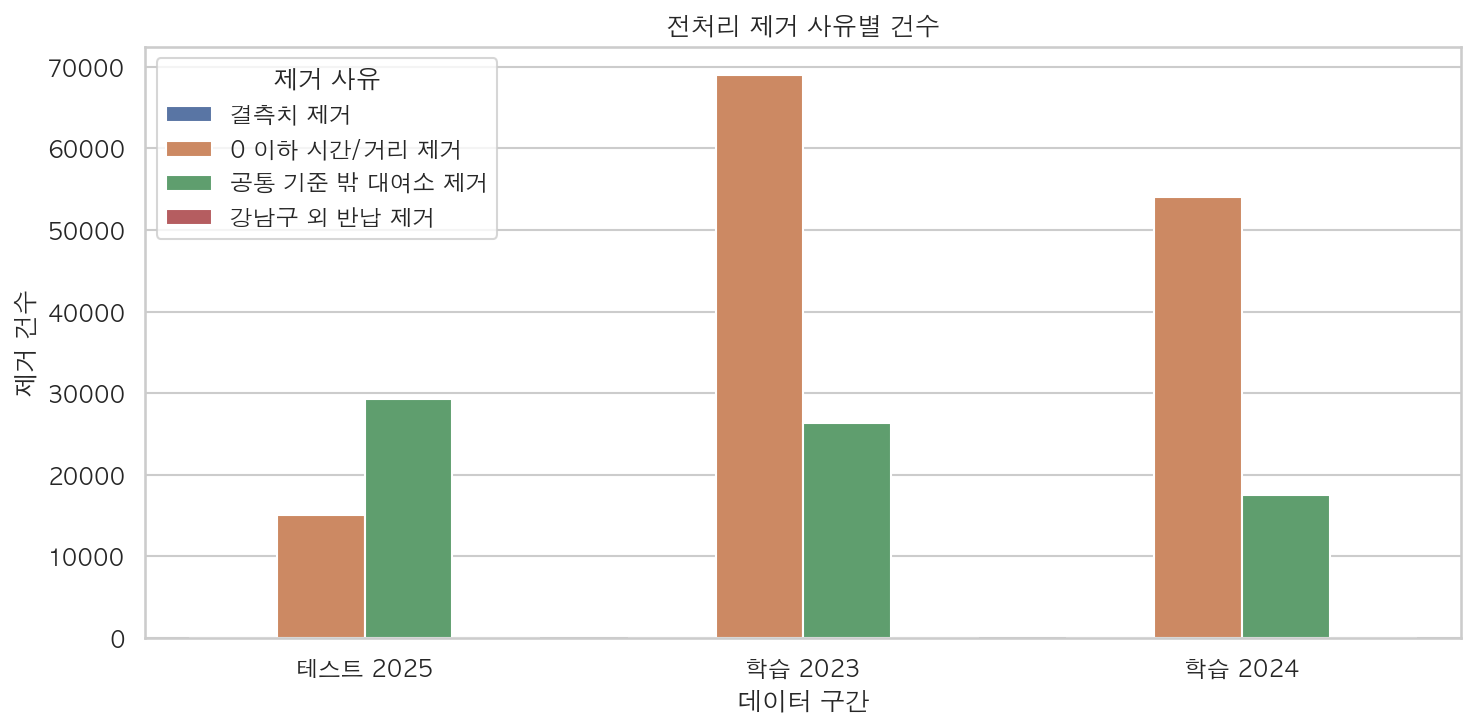

ddri_duplicate_rate.png exists= True


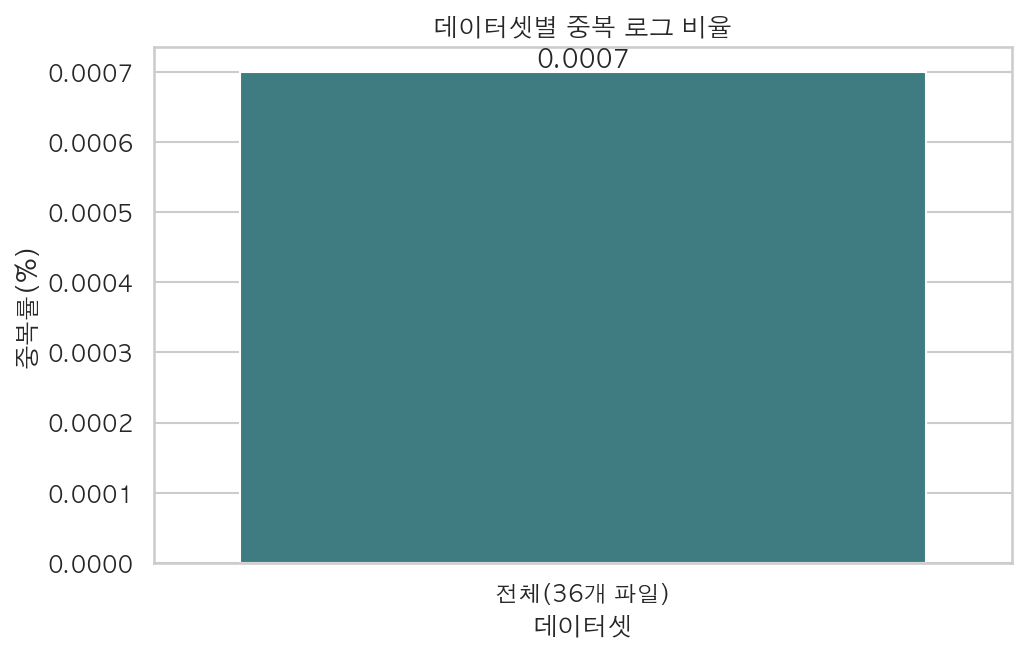

ddri_feature_iqr_outlier_counts.png exists= True


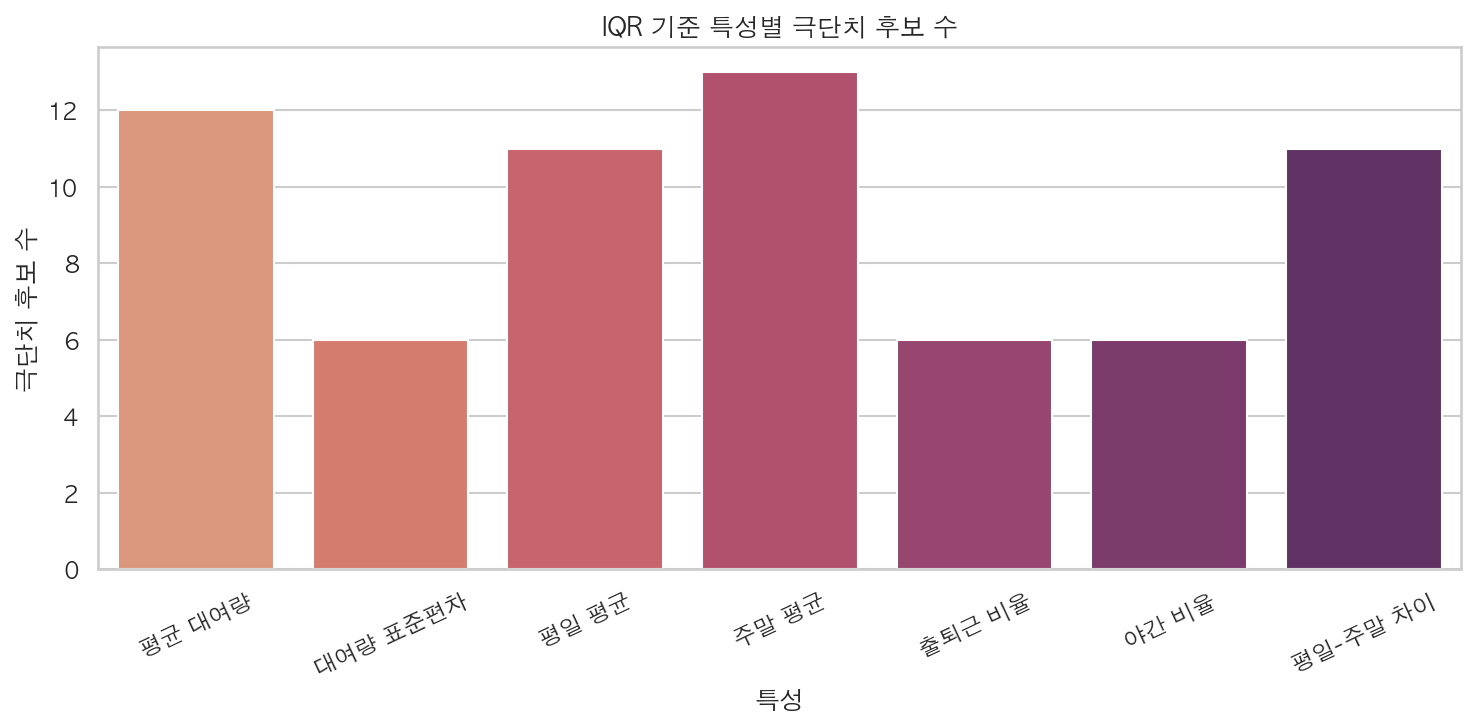

In [5]:
for image_name in [
    'ddri_cleaning_before_after.png',
    'ddri_cleaning_drop_reasons.png',
    'ddri_duplicate_rate.png',
    'ddri_feature_iqr_outlier_counts.png',
]:
    image_path = IMG_DIR / image_name
    print(image_name, 'exists=', image_path.exists())
    if image_path.exists():
        display(Image(filename=image_path))

## 6. 전처리 해석 정리

- 결측치와 비정상 시간/거리 값은 반드시 제거한다.
- 공통 기준 밖 대여소와 강남구 외 반납은 baseline에서 제외한다.
- self-return 중 5분 이하 즉시 반납은 제거하고, 그 외 기록은 운영 해석용 보조 지표 후보로 유지한다.
- 극단치 후보는 존재하지만, 실제 고수요 거점일 가능성이 있어 자동 제거보다는 별도 검토가 적절하다.